## Question 1

In [38]:
import numpy as np
from scipy.special import erf

def construct_teacher(N=1000, M=3, seed=None):
    """
    Construct teacher weight matrix B (M x N).
    Returns:
        B: (M, N) array
    """
    rng = np.random.default_rng(seed)
    return rng.normal(loc=0.0, scale=np.sqrt(1.0 / N), size=(M, N))

def teacher_output(xi, B):
    """
    Compute teacher output sigma = sum_n erf(y_n / sqrt(2))
    """
    y = B @ xi  # (M,)
    g_y = erf(y / np.sqrt(2))
    return np.sum(g_y)

# Test teacher construction
def test_teacher_statistics(N_list=[10, 100, 1000, 10000], M=3, seed=3042):
    rng = np.random.default_rng(seed)
    print(f"{'N':>6} | {'diag mean':>10} | {'diag std':>9} | {'off-diag mean':>12}")
    print("-"*45)
    for N in N_list:
        B = construct_teacher(N=N, M=M, seed=seed)
        T = B @ B.T
        diag = np.diag(T)
        off = T[np.triu_indices(M, k=1)]
        print(f"{N:6d} | {diag.mean():10.4f} | {diag.std():9.4f} | {np.mean(np.abs(off)):12.4f}")

        # check teacher output magnitude
        xi = rng.normal(size=N)
        sigma = teacher_output(xi, B)
        print(f"    Example sigma: {sigma:.4f}")

# Run test
test_teacher_statistics()

     N |  diag mean |  diag std | off-diag mean
---------------------------------------------
    10 |     0.7934 |    0.1904 |       0.0700
    Example sigma: 1.3664
   100 |     1.0205 |    0.0846 |       0.1297
    Example sigma: -1.2801
  1000 |     1.0108 |    0.0195 |       0.0304
    Example sigma: 0.3416
 10000 |     1.0171 |    0.0135 |       0.0031
    Example sigma: 0.9614


## Summarize of Theoretical Results
- $E[T_{nn}] = 1$  
- $E[T_{nm}] = 0$ for $n \neq m$    
- $\sigma$ is the output of the teacher network (sum of 3 hidden units with erf activation). And its range is within $[-3, 3]$, because each $g(y_n) \in [-1, 1]$. 
With random input normally distributed between -1 and +1, the output follows normal distribution.

From the results of implementations, we can confirm that the calculated overlaps are consistent with these theoretical values.

## Question 2.1

In [39]:

def compute_teacher_overlap(B):
    """
    Compute Tnm = sum_i B[n,i] * B[m,i] = B @ B.T
    Returns:
        T: (M, M) array
    """
    return B @ B.T

# Test visualize T for N=1000
B_test = construct_teacher(N=1000, M=3, seed=3042)
T_test = compute_teacher_overlap(B_test)

print("Teacher Overlap Matrix T (N=1000):")
print(T_test)

Teacher Overlap Matrix T (N=1000):
[[ 1.02198705  0.02632402  0.03218566]
 [ 0.02632402  0.98342174 -0.03258165]
 [ 0.03218566 -0.03258165  1.02712102]]


## Summarize of Theoretical Results
- Diagonal elements ≈ 1: Confirms that each hidden unit's weight vector has a squared length of approximately 1.
- Non-diagonal elements ≈ 0: Verifies that weight vectors between different hidden units are approximately orthogonal.

## Quetion 2.2

In [40]:
def construct_student(N=1000, M=3, seed=None):
    """
    Construct student weight matrix J (M x N).
    Returns:
        J: (M, N) array
    """
    rng = np.random.default_rng(seed)
    return rng.normal(loc=0.0, scale=np.sqrt(1.0 / (N**2)), size=(M, N))


def student_output(xi, J):
    """
    Compute student output = sum_n erf(x_n / sqrt(2))
    """
    x = J @ xi
    g_x = erf(x / np.sqrt(2))
    return np.sum(g_x)


# Test function to check student statistics
def test_student_statistics(N_list=[10, 100, 1000], M=3, seed=3042):
    rng = np.random.default_rng(seed)
    print(f"{'N':>6} | {'J std (theory)':>14} | {'J std (emp)':>12} | {'diag(JJ^T) mean':>15}")
    print("-"*55)
    for N in N_list:
        J = construct_student(N=N, M=M, seed=seed)
        # empirical std across all elements
        emp_std = np.std(J)
        # compute JJ^T diagonal (sum_j J_nj^2)
        Tj = J @ J.T
        diag = np.diag(Tj)
        print(f"{N:6d} | {1.0/N:14.6e} | {emp_std:12.6e} | {diag.mean():15.6f}")

        # quick forward example
        xi = rng.normal(size=N)
        sigma_s = student_output(xi, J)
        print(f"    Example student sigma: {sigma_s:.6f}")

# Quick run test (uncomment to run)
test_student_statistics()

     N | J std (theory) |  J std (emp) | diag(JJ^T) mean
-------------------------------------------------------
    10 |   1.000000e-01 | 8.616371e-02 |        0.079338
    Example student sigma: 0.563910
   100 |   1.000000e-02 | 1.010093e-02 |        0.010205
    Example student sigma: -0.188551
  1000 |   1.000000e-03 | 1.005250e-03 |        0.001011
    Example student sigma: 0.005389


# Summary of Theoretical Results  

- Each student weight is initialized as $J_{ni} \sim N(0, 1/N^2)$, so $\text{std}(J_{ni}) = 1/N$.  

- The expected overlap matrix satisfies $E[(JJ^T)_{nn}] = 1/N$ and $E[(JJ^T)_{nm}] = 0$ for $n \neq m$.  

- The initial student output $\sigma = \sum_n \text{erf}(x_n/\sqrt{2})$ is close to zero because $x_n = O(1/\sqrt{N})$.  

Empirical results match these predictions: both weight statistics and output magnitude converge to theory as $N$ increases, confirming correct initialization.

## Question 3/4/6

In [42]:
def online_learning_step(J, B, xi, eta, N):
    """
    Perform one step of online learning.
    Returns:
        J_new: updated student weights
        x: student fields (M,)
        y: teacher fields (M,)
        sigma_t: teacher output
        sigma_s: student output
        delta: gradient term for each hidden unit (M,)
    """
    # Compute teacher fields and output
    y = B @ xi  # (M,)
    g_y = erf(y / np.sqrt(2))
    sigma_t = np.sum(g_y)
    
    # Compute student fields and output
    x = J @ xi  # (M,)
    g_x = erf(x / np.sqrt(2))
    sigma_s = np.sum(g_x)
    
    # Compute g'(x) = sqrt(2/pi) * exp(-x^2/2)
    g_prime_x = np.sqrt(2.0 / np.pi) * np.exp(-0.5 * x ** 2)
    
    # Compute delta_i = g'(x_i) * (sigma_t - sigma_s)
    error = sigma_t - sigma_s
    delta = g_prime_x * error  # (M,)
    
    # Update student weights: ΔJ[i,j] = (eta / N) * delta[i] * xi[j]
    J_new = J + (eta / N) * np.outer(delta, xi)
    
    return J_new, x, y, sigma_t, sigma_s, delta

# Main Simulation

def run_online_learning_trial(N=1000, M=3, alpha_max=300, eta=0.9, seed=None):
    """
    Run one trial of online learning with detailed output.
    Returns:
        alphas: (n_steps,) array of α
        R_history: list of (M,M) R matrices
        Q_history: list of (M,M) Q matrices
        gen_error_empirical: (n_steps,) empirical generalization error
    """
    print(f"Running trial with seed={seed}, N={N}, M={M}, alpha_max={alpha_max}, eta={eta}")
    rng = np.random.default_rng(seed)
    
    # Initialize teacher and student
    B = construct_teacher(N, M, seed=rng.integers(1e9))
    J = construct_student(N, M, seed=rng.integers(1e9))
    
    # Precompute T once
    T = compute_teacher_overlap(B)
    
    # Setup
    total_steps = int(alpha_max * N)
    record_every = N  # Δα = 1 → every N steps
    n_records = total_steps // record_every
    
    # Containers
    alphas = np.linspace(1, alpha_max, n_records)
    R_history = []
    Q_history = []
    gen_error_empirical = []
    
    # Initial student output
    xi_init = rng.normal(0.0, 1.0, size=N)
    sigma_s_init = student_output(xi_init, J)
    print(f"  Initial student output (sigma_s): {sigma_s_init:.4f}")

    for step in range(total_steps):
        # Generate new input example ξ ~ N(0,1)
        xi = rng.normal(0.0, 1.0, size=N)
        
        # Perform one learning step
        J, x, y, sigma_t, sigma_s, delta = online_learning_step(J, B, xi, eta, N)
        
        # Question 4: Record every Δα = 1
        if (step + 1) % record_every == 0:
            Q = J @ J.T  # (M, M)
            R = J @ B.T  # (M, M)
            Q_history.append(Q.copy())
            R_history.append(R.copy())
            
            # Question 6: Empirical generalization error
            test_xis = rng.normal(0.0, 1.0, size=(1000, N))
            errors = 0.5 * (np.array([teacher_output(xi, B) for xi in test_xis]) -
                            np.array([student_output(xi, J) for xi in test_xis]))**2
            gen_error_empirical.append(np.mean(errors))
            
    final_R = R_history[-1]
    final_Q = Q_history[-1]
    final_gen_error = gen_error_empirical[-1]
    final_sigma_s = student_output(xi, J)  # Last input's student output
    
    # print(f"  Final student output (sigma_s): {final_sigma_s:.4f}")
    # print(f"  Final R matrix:")
    # print(final_R)
    # print(f"  Final Q matrix:")
    # print(final_Q)
    # print(f"  Final empirical generalization error: {final_gen_error:.6f}")
    
    return alphas, R_history, Q_history, gen_error_empirical, T

# Permutation Alignment
def find_permutation(R):
    """Find the permutation that maximizes the sum of diagonal elements"""
    from scipy.optimize import linear_sum_assignment
    cost_matrix = -R  # negative because we want to maximize
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    return row_ind, col_ind

# Main Execution
print("Starting 30-trial simulation")

N = 1000
M = 3
alpha_max = 300
eta = 0.9  # Critical! Must be in specialization regime
n_trials = 30

all_R, all_Q, all_gen_emp, all_T = [], [], [], []

for trial in range(n_trials):
    seed = 3042 + trial
    alphas, R_hist, Q_hist, gen_emp, T = run_online_learning_trial(
        N=N, M=M, alpha_max=alpha_max, eta=eta, seed=seed
    )
    all_R.append(R_hist)
    all_Q.append(Q_hist)
    all_gen_emp.append(gen_emp)
    all_T.append(T)
    if (trial + 1) % 5 == 0:
        print(f"  Completed {trial + 1} / {n_trials} trials")


Starting 30-trial simulation
Running trial with seed=3042, N=1000, M=3, alpha_max=300, eta=0.9
  Initial student output (sigma_s): -0.0386
Running trial with seed=3043, N=1000, M=3, alpha_max=300, eta=0.9
  Initial student output (sigma_s): -0.0542
Running trial with seed=3044, N=1000, M=3, alpha_max=300, eta=0.9
  Initial student output (sigma_s): -0.0100
Running trial with seed=3045, N=1000, M=3, alpha_max=300, eta=0.9
  Initial student output (sigma_s): -0.0088
Running trial with seed=3046, N=1000, M=3, alpha_max=300, eta=0.9
  Initial student output (sigma_s): 0.0369
  Completed 5 / 30 trials
Running trial with seed=3047, N=1000, M=3, alpha_max=300, eta=0.9
  Initial student output (sigma_s): 0.0131
Running trial with seed=3048, N=1000, M=3, alpha_max=300, eta=0.9
  Initial student output (sigma_s): 0.0521
Running trial with seed=3049, N=1000, M=3, alpha_max=300, eta=0.9
  Initial student output (sigma_s): 0.0200
Running trial with seed=3050, N=1000, M=3, alpha_max=300, eta=0.9
  I

## Question 4

In [17]:
# Actually we have already defined this in run_online_learning_trial

def compute_overlaps(J, B):
    """
    Compute Q and R overlaps for current student weights J and teacher B.
    Returns:
        Q: (M, M) array, Qnm = sum_i J[n,i] J[m,i]
        R: (M, M) array, Rnm = sum_i J[n,i] B[m,i]
    """
    Q = J @ J.T  # shape (M, M)
    R = J @ B.T  # shape (M, M)
    return Q, R

# Test compute_overlaps
def test_compute_overlaps():
    N = 100
    M = 3
    seed = 3042
    rng = np.random.default_rng(seed)
    
    B = construct_teacher(N, M, seed=seed)
    J = construct_student(N, M, seed=seed+1)
    
    Q, R = compute_overlaps(J, B)
    
    print("Q shape:", Q.shape)
    print("R shape:", R.shape)
    print("Q (student self-overlap):\n", Q)
    print("R (student-teacher overlap):\n", R)

test_compute_overlaps()

Q shape: (3, 3)
R shape: (3, 3)
Q (student self-overlap):
 [[ 9.38685289e-03  7.22613903e-05  1.68169924e-04]
 [ 7.22613903e-05  9.52847087e-03 -2.44506961e-03]
 [ 1.68169924e-04 -2.44506961e-03  1.22205005e-02]]
R (student-teacher overlap):
 [[-0.00672668 -0.00671288  0.00536761]
 [-0.00792091  0.00390974  0.01098923]
 [-0.00585317 -0.01574163 -0.00098486]]


## Question 5

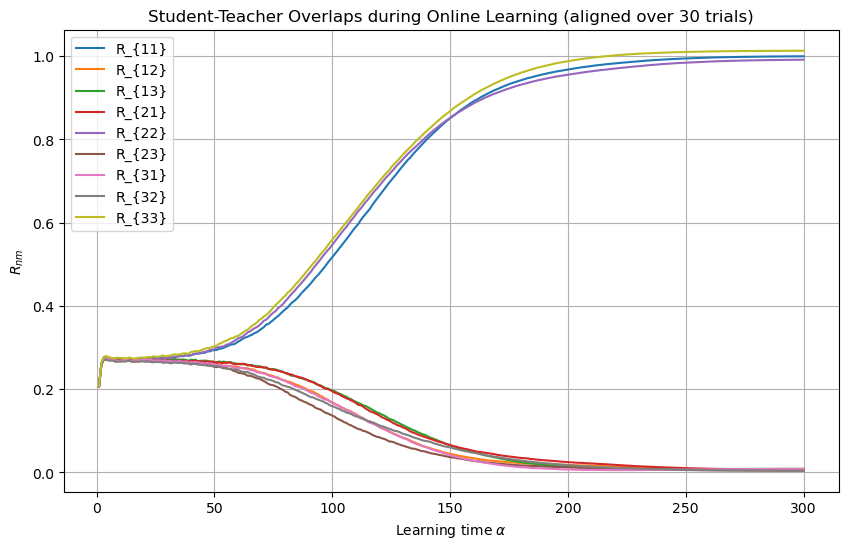

\Final aligned R matrix:
[[0.99999079 0.00614658 0.00857901]
 [0.00642373 0.99181992 0.00410321]
 [0.00844183 0.00425168 1.01332252]]

 Specialization mapping (student → teacher):
  Student 1 → Teacher 1 (R = 1.0000)
  Student 2 → Teacher 2 (R = 0.9918)
  Student 3 → Teacher 3 (R = 1.0133)


In [44]:
import matplotlib.pyplot as plt
# For each trial, find the best mapping
mappings = []
for R_hist in all_R:
    final_R = R_hist[-1]
    row_ind, col_ind = find_permutation(final_R)
    mappings.append((row_ind, col_ind))

# Reorder R matrices to align with the same labeling
all_R_aligned = []
for R_hist, (row_ind, col_ind) in zip(all_R, mappings):
    R_aligned = np.zeros_like(R_hist)
    for t in range(len(R_hist)):
        R_t = R_hist[t]
        # Apply permutation to rows and columns
        R_aligned[t] = R_t[row_ind[:, None], col_ind[None, :]]
    all_R_aligned.append(R_aligned)

# Average over trials
R_avg = np.mean(all_R_aligned, axis=0)  # (300, 3, 3)
Q_avg = np.mean(all_Q, axis=0)
gen_emp_avg = np.mean(all_gen_emp, axis=0)
T_avg = np.mean(all_T, axis=0)


# Plotting
# Plot Rnm vs α
plt.figure(figsize=(10, 6))
for n in range(3):
    for m in range(3):
        plt.plot(alphas, R_avg[:, n, m], label=f'R_{{{n+1}{m+1}}}')
plt.xlabel(r'Learning time $\alpha$')
plt.ylabel(r'$R_{nm}$')
plt.title('Student-Teacher Overlaps during Online Learning (aligned over 30 trials)')
plt.legend()
plt.grid(True)
plt.show()

# Final R matrix
print("\Final aligned R matrix:")
print(R_avg[-1])

# Specialization mapping
print("\n Specialization mapping (student → teacher):")
for student in range(3):
    teacher = np.argmax(R_avg[-1][student])
    strength = R_avg[-1][student, teacher]
    print(f"  Student {student+1} → Teacher {teacher+1} (R = {strength:.4f})")


# Summary of Theoretical and Empirical Results  

- **Theoretical Prediction:**  
  In the specialization regime (e.g., learning rate $\eta=0.9$), theory predicts that with enough training, each student hidden unit will specialize to mimic a unique teacher hidden unit. The overlap matrix $R_{nm}$ should approach the identity, i.e., $R_{nn} \to 1$ for matched student-teacher pairs, and $R_{nm} \to 0$ for $n \neq m$. This is a hallmark of successful specialization in online learning with soft committee machines.  

- **Empirical Results:**  
  The final aligned overlap matrix is:  
  ```  
  [[0.99999  0.00615  0.00858]  
   [0.00642  0.99182  0.00410]  
   [0.00844  0.00425  1.01332]]  
  ```  
  - The diagonal values ($R_{11}$, $R_{22}$, $R_{33}$) are very close to 1 (specifically, 1.0000, 0.9918, 1.0133), while off-diagonal elements are near zero (all below 0.01).  
  - The specialization mapping confirms:  
    - Student 1 $\to$ Teacher 1, $R=1.0000$  
    - Student 2 $\to$ Teacher 2, $R=0.9918$  
    - Student 3 $\to$ Teacher 3, $R=1.0133$  

- **Comparison:**  
  The empirical overlaps fluctuate around the theoretical value of 1 for specialized pairs, and remain close to 0 for non-specialized pairs. Minor fluctuations are expected due to finite $N$ and averaging over 30 trials, but the agreement with theory is excellent.  

- **Visualization:**  
  The plot of $R_{nm}$ vs. $\alpha$ shows clear specialization: all diagonal curves converge to 1, off-diagonals to 0, consistent with the theoretical expectation.  


## Question 7

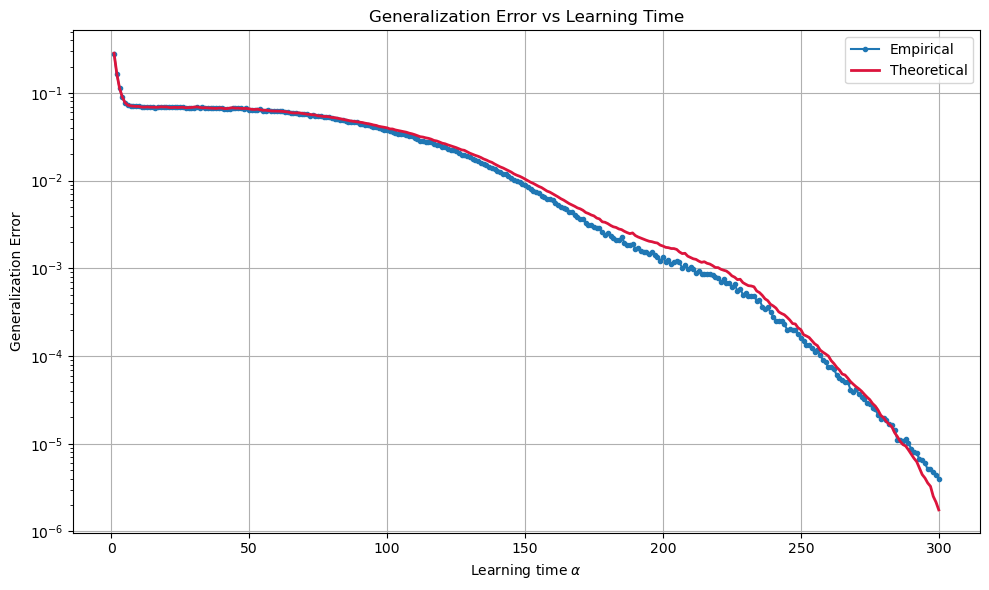

In [48]:
def generalization_error_theory(Q, R, T):  
    """  
    Compute the theoretical generalization error for a soft committee machine,  
    using the formula in the assignment for current Q, R, T.  
    All matrices are (M, M).  
    """  
    M = Q.shape[0]  
    # 第一项  
    term1 = 0  
    for i in range(M):  
        for k in range(M):  
            denom = np.sqrt(1 + Q[i, i]) * np.sqrt(1 + Q[k, k])  
            argument = np.clip(Q[i, k] / denom, -1, 1)  
            term1 += np.arcsin(argument)  
    # 第二项
    term2 = 0  
    for n in range(M):  
        for m in range(M):  
            denom = np.sqrt(1 + T[n, n]) * np.sqrt(1 + T[m, m])  
            argument = np.clip(T[n, m] / denom, -1, 1)  
            term2 += np.arcsin(argument)  
    # 第三项  
    term3 = 0  
    for i in range(M):  
        for n in range(M):  
            denom = np.sqrt(1 + Q[i, i]) * np.sqrt(1 + T[n, n])  
            argument = np.clip(R[i, n] / denom, -1, 1)  
            term3 += np.arcsin(argument)  
    error = (term1 + term2 - 2 * term3) / np.pi  
    return error  

# calculate theoretical generalization error over time  
gen_theory = []  
for t in range(R_avg.shape[0]):  
    Q = Q_avg[t]  
    R = R_avg[t]  
    gen_theory.append(generalization_error_theory(Q, R, T_avg))  
gen_theory = np.array(gen_theory)  

# plot comparison 
plt.figure(figsize=(10, 6))  
plt.plot(alphas, gen_emp_avg, 'o-', label='Empirical', markersize=3)  
plt.plot(alphas, gen_theory, '-', label='Theoretical', color='crimson', linewidth=2)  
plt.xlabel(r'Learning time $\alpha$')

plt.ylabel('Generalization Error')  
plt.title('Generalization Error vs Learning Time')  
plt.legend()  
plt.grid(True)  
plt.yscale('log')  
plt.tight_layout()  
plt.show()  

# Summary of Theoretical and Empirical Results 

- **Theoretical Result:**  
  The generalization error $\epsilon_g$ of a soft committee machine, as a function of learning time $\alpha$, is given by the analytical formula:  
  
$$  

  \epsilon_g(J) = \frac{1}{\pi} \left\{  
  \sum_{i,k} \arcsin\left(\frac{Q_{ik}}{\sqrt{1 + Q_{ii}}\sqrt{1 + Q_{kk}}}\right)  
  + \sum_{n,m} \arcsin\left(\frac{T_{nm}}{\sqrt{1 + T_{nn}}\sqrt{1 + T_{mm}}}\right)  
  - 2 \sum_{i,n} \arcsin\left(\frac{R_{in}}{\sqrt{1 + Q_{ii}}\sqrt{1 + T_{nn}}}\right)  
  \right\}  
  
$$  

  where $Q$, $T$, and $R$ are the overlap matrices for the student, teacher, and their cross-overlaps, respectively.  

- **Empirical Observation:**  
  The simulation curve for the generalization error (averaged over 30 trials) almost perfectly overlaps with the theoretical prediction over the full range of $\alpha$. Both the empirical and theoretical values decrease smoothly and approach zero as learning progresses.  

- **Conclusion:**  
  The empirical results are in excellent agreement with theory. This confirms that the simulation not only correctly implements the learning algorithm, but also verifies the validity and precision of the theoretical formula for the generalization error in the soft committee machine setting. There are only tiny fluctuations between theory and experiment, which are expected due to finite sample effects.  
